In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import random
from dataclasses import dataclass
import matplotlib.pyplot as plt
from multiarm_bandits import *

In [3]:
def run_experiments(config, epsilon, steps=1000, nums=200):
    reward_result = []
    optimal_ratio_result = []
    for _ in range(nums):
        bandits = initialize_bandits(config)
        karm_bandits = KArmBandits(config.k, epsilon, bandits)
        avg_reward, optimal_ratio = karm_bandits.play(steps)
        reward_result.append(avg_reward)
        optimal_ratio_result.append(optimal_ratio)
    
    return np.array(reward_result), np.array(optimal_ratio_result)

def run_experiments_ucb(config, c=1.0, steps=1000, nums=200):
    reward_result = []
    optimal_ratio_result = []
    for _ in range(nums):
        bandits = initialize_bandits(config)
        karm_bandits = KArmBanditsUCB(config.k, bandits, c)
        avg_reward, optimal_ratio = karm_bandits.play(steps)
        reward_result.append(avg_reward)
        optimal_ratio_result.append(optimal_ratio)
    
    return np.array(reward_result), np.array(optimal_ratio_result)

## Vanilla k-arm bandits

- update: sample average
- action: $\epsilon$ greedy

### reward std = 1.0

In [4]:
config = KArmBanditsConfig(k=10, max_reward=3, min_reward=-3, reward_std=1.0)

In [5]:
eps = [0, 0.01, 0.1, 0.3, 0.5]
reward = {}
optimal_ratio = {}
for e in eps:
    r, o = run_experiments(config, e, 1000, 2000)
    reward[e] = np.mean(r, axis=0)
    optimal_ratio[e] = np.mean(o, axis=0)

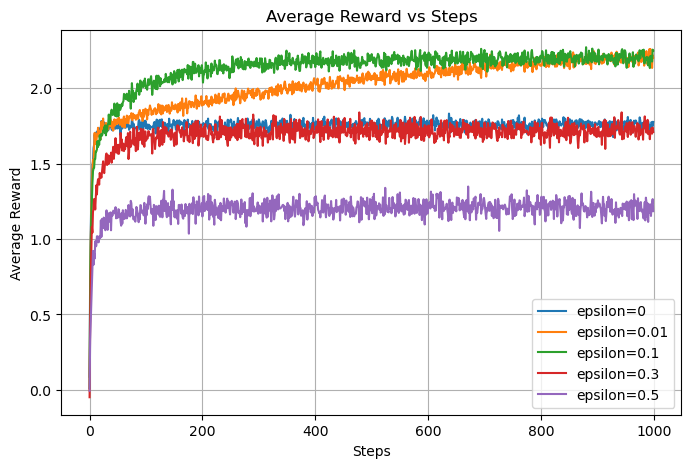

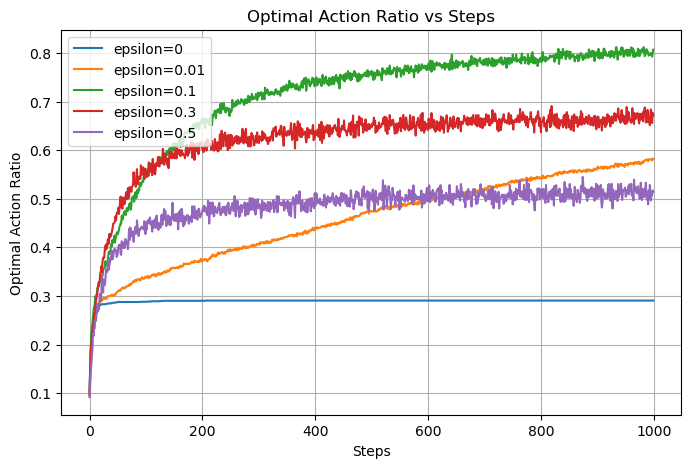

In [6]:
# Plot average reward
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(reward[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot optimal action ratio
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(optimal_ratio[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Optimal Action Ratio")
plt.title("Optimal Action Ratio vs Steps")
plt.legend()
plt.grid(True)
plt.show()

### reward std = 10.0 

In [9]:
config = KArmBanditsConfig(k=10, max_reward=3, min_reward=-3, reward_std=10.0)
bandits = initialize_bandits(config)

eps = [0, 0.01, 0.1, 0.3, 0.5]
reward = {}
optimal_ratio = {}
for e in eps:
    r, o = run_experiments(config, e, 1000, 2000)
    reward[e] = np.mean(r, axis=0)
    optimal_ratio[e] = np.mean(o, axis=0)

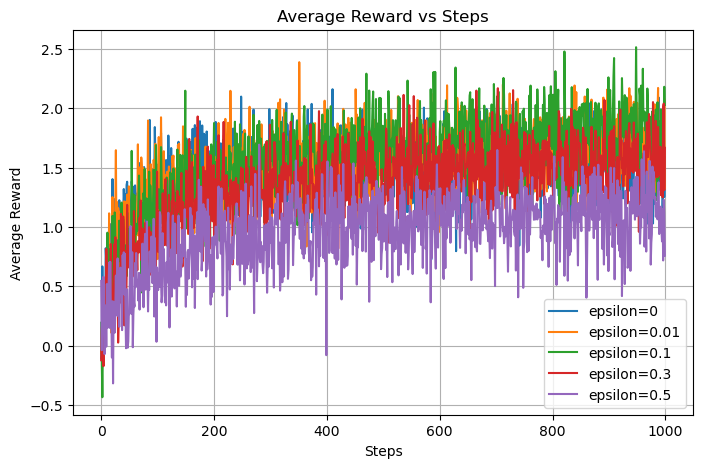

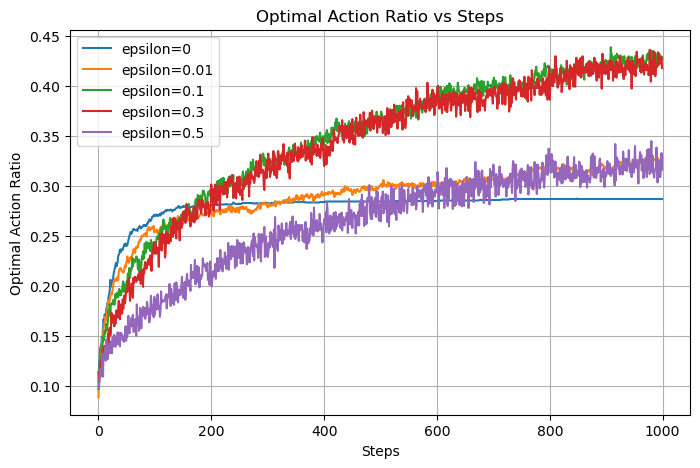

In [10]:
# Plot average reward
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(reward[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot optimal action ratio
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(optimal_ratio[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Optimal Action Ratio")
plt.title("Optimal Action Ratio vs Steps")
plt.legend()
plt.grid(True)
plt.show()

## UCB vs $\epsilon$-greedy

Replicate Figure 2.4

In [11]:
eps_greedy_p1 = run_experiments(config, 0.1, steps=1000, nums=2000)
ucb_2 = run_experiments_ucb(config, c=2.0, steps=1000, nums=2000)

In [12]:
reward_eps_greedy = np.mean(eps_greedy_p1[0], axis=0)
reward_ucb = np.mean(ucb_2[0], axis=0)

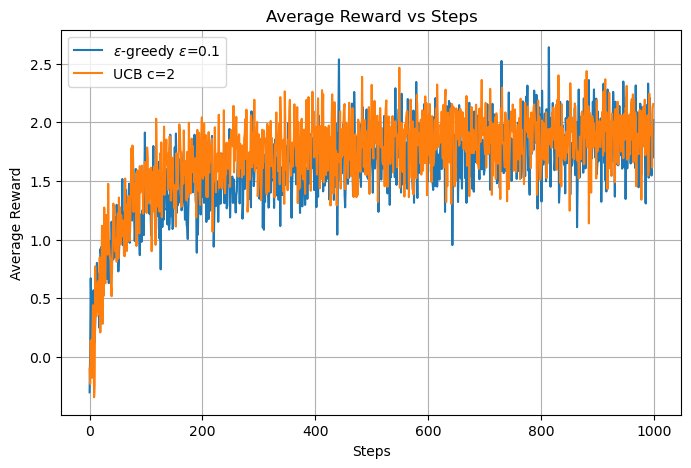

In [13]:
# Plot average reward
plt.figure(figsize=(8, 5))

plt.plot(reward_eps_greedy, label=r"$\epsilon$-greedy $\epsilon$=0.1")
plt.plot(reward_ucb, label="UCB c=2")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()